# CompCars Web-Nature (Showroom) Fine-Grained Classification
## Transfer Learning with EfficientNetB0 (Using Bounding Box Cropping)
This notebook trains an **EfficientNetB0** model on the **CompCars Web-Nature (Showroom/Catalog)** dataset across 431 benchmark car models.
Images are cropped using the official annotated **bounding boxes** (`label/` directory) before resizing and augmentation, focusing the model purely on the vehicle and removing background clutter.


### 1. Imports & Environment Setup


In [1]:
import os
from scipy.io import loadmat
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from PIL import Image

import tensorflow as tf
from tensorflow.keras.layers import Dense, Dropout, GlobalAveragePooling2D
from tensorflow.keras.models import Sequential
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.applications.efficientnet import preprocess_input
from sklearn.model_selection import train_test_split
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.utils import Sequence, to_categorical
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau


I0000 00:00:1788935520.681845 1179427 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1788935520.716628 1179427 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI AVX512_BF16 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1788935521.544511 1179427 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


### 2. Dataset Paths & Class Metadata (431 Benchmark Models)


In [2]:
DATA_DIR = "../../compcars_cctv/extracted/data_extracted/data"
IMG_DIR = os.path.join(DATA_DIR, "image")
LABEL_DIR = os.path.join(DATA_DIR, "label")
SPLIT_DIR = os.path.join(DATA_DIR, "train_test_split", "classification")

# Load make and model names metadata
meta = loadmat(os.path.join(DATA_DIR, "misc", "make_model_name.mat"), simplify_cells=True)
make_names = meta["make_names"]    # 163 makes
model_names = meta["model_names"]  # 2004 models


FileNotFoundError: [Errno 2] No such file or directory: '../../compcars_cctv/extracted/data_extracted/data/misc/make_model_name.mat'

In [ ]:
IMG_SIZE = (224, 224)
BATCH_SIZE = 32

# Load official train and test splits to extract the 431 benchmark models
with open(os.path.join(SPLIT_DIR, "train.txt"), "r") as f:
    train_lines = [l.strip() for l in f if l.strip()]

with open(os.path.join(SPLIT_DIR, "test.txt"), "r") as f:
    test_lines = [l.strip() for l in f if l.strip()]

# Extract unique model IDs used in the classification benchmark
unique_models = sorted(list(set(int(l.split("/")[1]) for l in train_lines)))
NUM_CLASSES = len(unique_models)  # 431 models

# Map 1-based model_id to 0-based sequential class index [0 .. 430]
model_to_label = {model_id: idx for idx, model_id in enumerate(unique_models)}
label_to_model = {idx: model_id for idx, model_id in enumerate(unique_models)}

# Human-readable class names for the 431 models
class_names = [model_names[m - 1] for m in unique_models]

print(f"Total Benchmark Classes: {NUM_CLASSES}")
print("Sample class names (first 10):")
for i in range(10):
    print(f"  Class {i} (model_id {label_to_model[i]}): {class_names[i]}")


Total Benchmark Classes: 431
Sample class names (first 10):
  Class 0 (model_id 1): Audi A3 hatchback
  Class 1 (model_id 2): Audi A4L
  Class 2 (model_id 3): Audi A6L
  Class 3 (model_id 4): Audi Q3
  Class 4 (model_id 5): Audi Q5
  Class 5 (model_id 11): Audi A3 sedan
  Class 6 (model_id 19): Audi A1
  Class 7 (model_id 21): Audi A4 estate
  Class 8 (model_id 22): Audi A5 convertible
  Class 9 (model_id 23): Audi A5 coupe


### 3. Load Training Dataset with Bounding Boxes


In [ ]:
rows = []
for rel_path in train_lines:
    parts = rel_path.split("/")
    make_id = int(parts[0])
    model_id = int(parts[1])
    year = parts[2]
    image_name = parts[3]

    # Parse bounding box and viewpoint from corresponding label file
    label_file = os.path.join(LABEL_DIR, os.path.splitext(rel_path)[0] + ".txt")
    with open(label_file, "r") as lf:
        lbl_lines = lf.readlines()
    
    viewpoint = int(lbl_lines[0].strip())
    x1, y1, x2, y2 = [int(v) for v in lbl_lines[2].strip().split()]

    rows.append({
        "image": image_name,
        "make_id": make_id,
        "model_id": model_id,
        "make_name": make_names[make_id - 1],
        "class_name": model_names[model_id - 1],
        "label": model_to_label[model_id],
        "viewpoint": viewpoint,
        "bbox_x1": x1,
        "bbox_y1": y1,
        "bbox_x2": x2,
        "bbox_y2": y2,
        "file_path": os.path.join(IMG_DIR, rel_path)
    })

df = pd.DataFrame(rows)
print(f"Total training images: {len(df)}")
df.head()


Total training images: 16016


,image,make_id,model_id,make_name,class_name,label,viewpoint,bbox_x1,bbox_y1,bbox_x2,bbox_y2,file_path
0,439374a1456969.jpg,78,1,Audi,Audi A3 hatchback,0,1,131,111,765,568,../../compcars_cctv/extracted/data_extracted/d...
1,6c5730eb35dbfc.jpg,78,1,Audi,Audi A3 hatchback,0,1,154,102,752,510,../../compcars_cctv/extracted/data_extracted/d...
2,a2b9bfe21409f4.jpg,78,1,Audi,Audi A3 hatchback,0,1,162,130,771,589,../../compcars_cctv/extracted/data_extracted/d...
3,043602fa21a621.jpg,78,1,Audi,Audi A3 hatchback,0,1,151,109,763,580,../../compcars_cctv/extracted/data_extracted/d...
4,ccc640bfa095e3.jpg,78,1,Audi,Audi A3 hatchback,0,1,160,129,745,555,../../compcars_cctv/extracted/data_extracted/d...


In [ ]:
df["class_name"].value_counts().describe()


count    431.000000
mean      37.160093
std       21.396259
min       10.000000
25%       20.000000
50%       31.000000
75%       50.000000
max      143.000000
Name: count, dtype: float64

### 4. Model Architecture: EfficientNetB0 + Classification Head


In [ ]:
base_model = EfficientNetB0(
    weights="imagenet",
    include_top=False,
    input_shape=(IMG_SIZE[0], IMG_SIZE[1], 3)
)
base_model.trainable = True
for layer in base_model.layers[:-5]:
    layer.trainable = False

model = Sequential([
    base_model,
    GlobalAveragePooling2D(),
    Dropout(0.5),
    Dense(NUM_CLASSES, dtype="float32", activation="softmax")
])


I0000 00:00:1788849460.037726   15698 gpu_device.cc:2043] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 5089 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 4060 Laptop GPU, pci bus id: 0000:01:00.0, compute capability: 8.9


KeyboardInterrupt: 

In [ ]:
model.compile(
    optimizer=Adam(learning_rate=1e-3),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)


In [ ]:
model.summary()


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ efficientnetb0 (Functional)     │ (None, 7, 7, 1280)     │     4,049,571 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 431)            │       552,111 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,601,682 (17.55 MB)

 Trainable params: 552,111 (2.11 MB)

 Non-trainable params: 4,049,571 (15.45 MB)

### 5. Train / Validation Split (Stratified 80/20)


In [ ]:
train_df, val_df = train_test_split(
    df,
    test_size=0.2,
    random_state=42,
    stratify=df["label"]
)
print(f"Training images: {len(train_df)}")
print(f"Validation images: {len(val_df)}")


Training images: 12812
Validation images: 3204


In [ ]:
train_df.head()


,image,make_id,model_id,make_name,class_name,label,viewpoint,bbox_x1,bbox_y1,bbox_x2,bbox_y2,file_path
9401,3395a289fb2fca.jpg,131,1015,Infiniti,Infiniti QX70,236,4,120,118,830,585,../compcars_cctv/extracted/data_extracted/data...
5209,5a67d76e9d7553.jpg,73,441,Volkswagen,Passat,127,4,64,182,831,541,../compcars_cctv/extracted/data_extracted/data...
7638,c2c0d4fb663b09.jpg,53,765,Cadillac,Cadillac CTS,187,5,71,130,849,593,../compcars_cctv/extracted/data_extracted/data...
13159,dd044438c4a5ca.jpg,162,1637,MAZDA,Axela sedan,344,3,76,256,834,502,../compcars_cctv/extracted/data_extracted/data...
2751,88beffdacf8698.jpg,54,194,Buck,Exclle,55,2,230,207,677,563,../compcars_cctv/extracted/data_extracted/data...


In [ ]:
val_df.head()


,image,make_id,model_id,make_name,class_name,label,viewpoint,bbox_x1,bbox_y1,bbox_x2,bbox_y2,file_path
10881,53cc0da7b59b3f.jpg,158,1258,Citroen,Citroen C4L,273,4,68,296,779,624,../compcars_cctv/extracted/data_extracted/data...
598,3dc1fc16892307.jpg,78,26,Audi,Audi A7,11,3,106,255,820,470,../compcars_cctv/extracted/data_extracted/data...
10681,ced84c577063b1.jpg,158,1251,Citroen,c-Elysee sedan,268,5,116,152,792,584,../compcars_cctv/extracted/data_extracted/data...
7020,c9ee47eda83ea2.jpg,134,661,FIAT,FIAT 500,176,5,63,171,844,626,../compcars_cctv/extracted/data_extracted/data...
1467,5d1663e0bfd99d.jpg,81,100,BWM,BWM 6 Series,29,1,155,109,750,601,../compcars_cctv/extracted/data_extracted/data...


### 6. Bounding Box Cropping, Data Augmentation & Generators


In [ ]:
from concurrent.futures import ThreadPoolExecutor

def _process_bbox_sample(args):
    file_path, bbox, target_size, datagen = args
    with Image.open(file_path) as img:
        cropped = img.crop(bbox).convert("RGB")
        resized = cropped.resize(target_size, Image.BILINEAR)
        arr = np.array(resized, dtype=np.float32)
    
    if datagen is not None:
        arr = datagen.random_transform(arr)
        arr = datagen.preprocessing_function(arr)
    else:
        arr = preprocess_input(arr)
    return arr

class BBoxDataGenerator(Sequence):
    """
    Custom Keras Sequence Generator that crops each car image according to its
    annotated bounding box coordinates [x1, y1, x2, y2] using high-throughput
    multithreading before resizing, augmenting, and feeding into the model.
    """
    def __init__(self, df, batch_size=32, target_size=(224, 224), num_classes=431, datagen=None, shuffle=True, workers=16, **kwargs):
        super().__init__(**kwargs)
        self.df = df.reset_index(drop=True)
        self.batch_size = batch_size
        self.target_size = target_size
        self.num_classes = num_classes
        self.datagen = datagen
        self.shuffle = shuffle
        self.workers = workers
        self.pool = ThreadPoolExecutor(max_workers=workers)
        self.indexes = np.arange(len(self.df))
        if self.shuffle:
            np.random.shuffle(self.indexes)

    def __len__(self):
        return int(np.ceil(len(self.df) / self.batch_size))

    def on_epoch_end(self):
        if self.shuffle:
            np.random.shuffle(self.indexes)

    def __getitem__(self, index):
        batch_indexes = self.indexes[index * self.batch_size:(index + 1) * self.batch_size]
        batch_df = self.df.iloc[batch_indexes]

        items = [
            (row["file_path"], (row["bbox_x1"], row["bbox_y1"], row["bbox_x2"], row["bbox_y2"]), self.target_size, self.datagen)
            for _, row in batch_df.iterrows()
        ]
        batch_x = list(self.pool.map(_process_bbox_sample, items))
        batch_y = batch_df["label"].values.astype(int)

        return np.array(batch_x, dtype=np.float32), to_categorical(batch_y, num_classes=self.num_classes)

    def close(self):
        self.pool.shutdown(wait=False)

train_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    rotation_range=15,
    width_shift_range=0.1,
    height_shift_range=0.1,
    zoom_range=0.15,
    horizontal_flip=True,
    brightness_range=(0.8, 1.2)
)

train_generator = BBoxDataGenerator(
    df=train_df,
    batch_size=BATCH_SIZE,
    target_size=IMG_SIZE,
    num_classes=NUM_CLASSES,
    datagen=train_datagen,
    shuffle=True,
    workers=16
)

val_generator = BBoxDataGenerator(
    df=val_df,
    batch_size=BATCH_SIZE,
    target_size=IMG_SIZE,
    num_classes=NUM_CLASSES,
    datagen=None,
    shuffle=False,
    workers=16
)


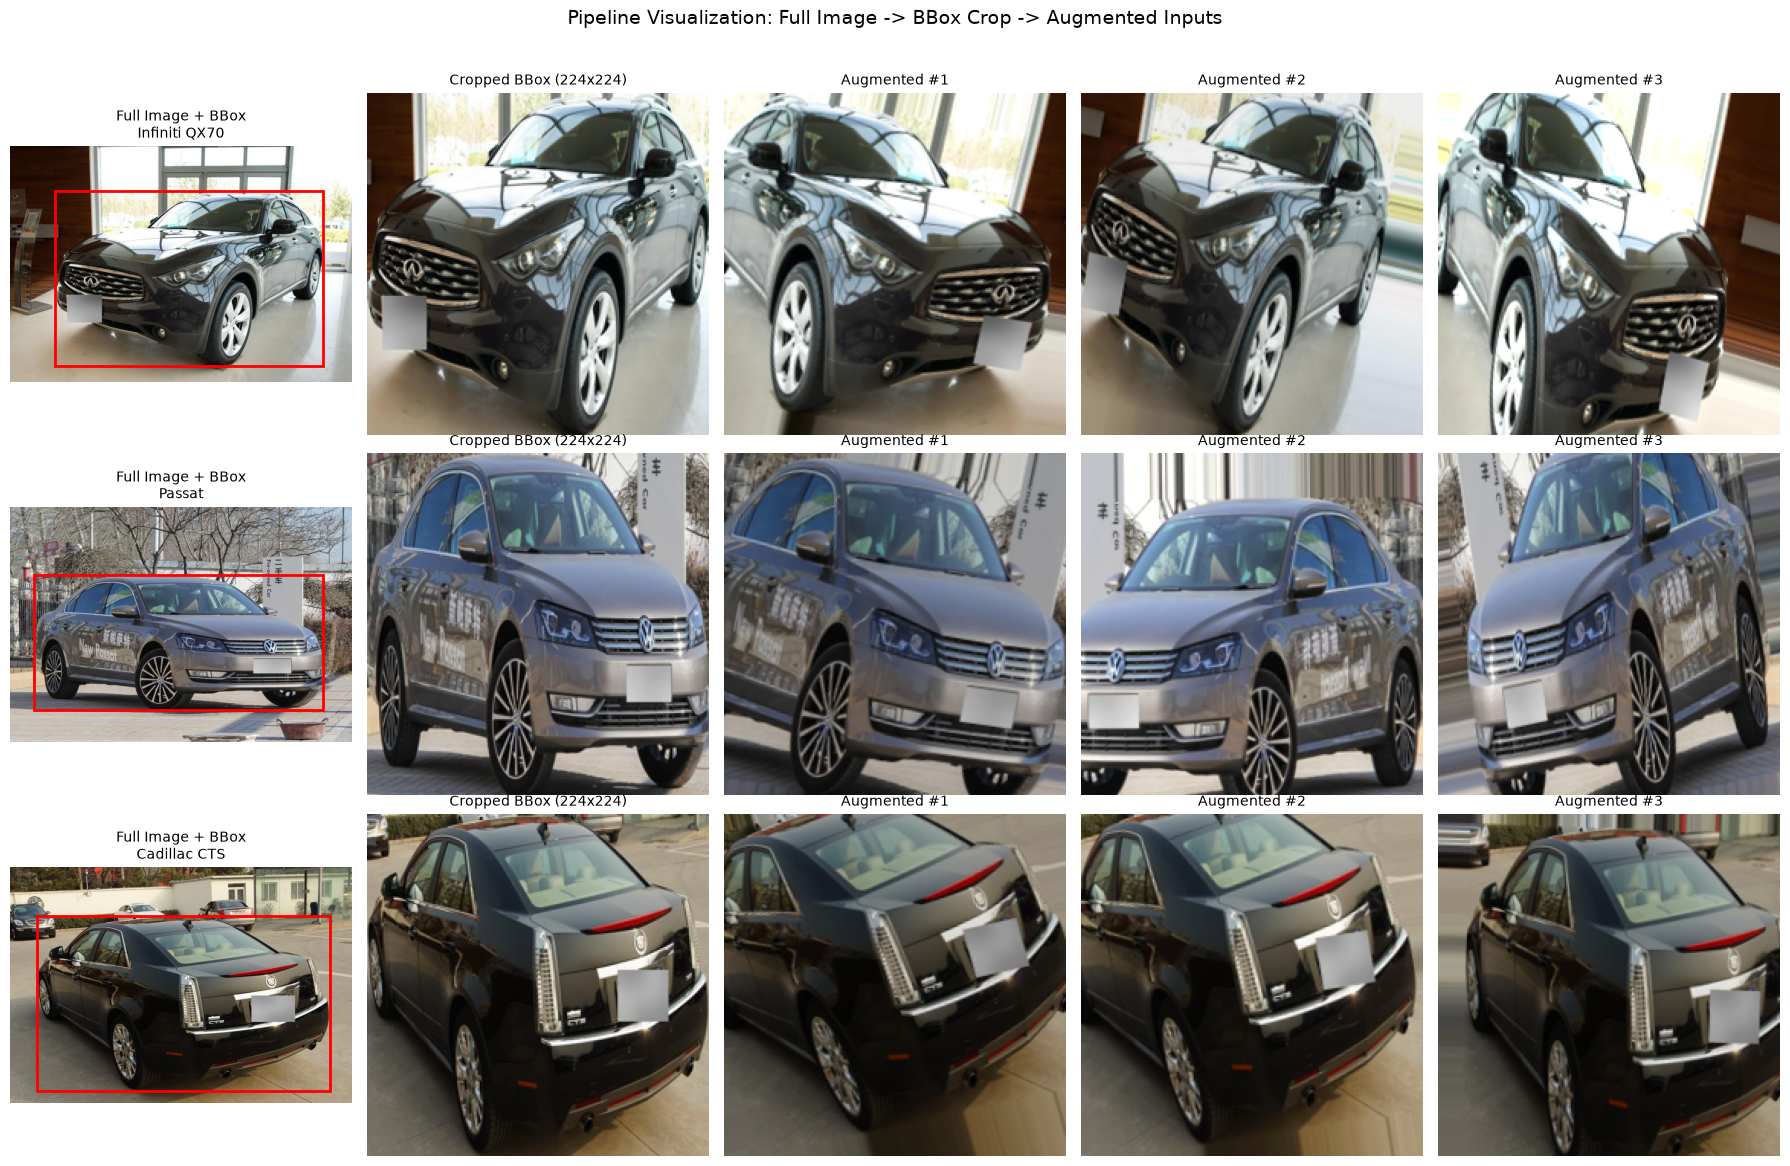

In [ ]:
# Visualize Bounding Box Cropping & Augmentations
sample_records = train_df.drop_duplicates(subset=["class_name"]).iloc[:3]
num_samples = len(sample_records)

fig, axes = plt.subplots(num_samples, 5, figsize=(18, 3.8 * num_samples))

for row_idx, (_, row) in enumerate(sample_records.iterrows()):
    with Image.open(row["file_path"]) as full_img:
        full_img_rgb = full_img.convert("RGB")
        # 1. Full Image with bounding box rectangle
        axes[row_idx, 0].imshow(full_img_rgb)
        rect = patches.Rectangle(
            (row["bbox_x1"], row["bbox_y1"]),
            row["bbox_x2"] - row["bbox_x1"],
            row["bbox_y2"] - row["bbox_y1"],
            linewidth=2,
            edgecolor="r",
            facecolor="none"
        )
        axes[row_idx, 0].add_patch(rect)
        axes[row_idx, 0].set_title(f"Full Image + BBox\n{row['class_name']}", fontsize=10)
        axes[row_idx, 0].axis("off")

        # 2. Cropped Bounding Box
        bbox = (row["bbox_x1"], row["bbox_y1"], row["bbox_x2"], row["bbox_y2"])
        cropped_img = full_img_rgb.crop(bbox).resize(IMG_SIZE)
        axes[row_idx, 1].imshow(cropped_img)
        axes[row_idx, 1].set_title("Cropped BBox (224x224)", fontsize=10)
        axes[row_idx, 1].axis("off")

        # 3. Augmented variations on the cropped vehicle
        img_arr = np.array(cropped_img, dtype=np.float32)
        for col_idx in range(2, 5):
            aug_img = train_datagen.random_transform(img_arr.copy())
            aug_display = np.clip(aug_img, 0, 255).astype("uint8")
            axes[row_idx, col_idx].imshow(aug_display)
            axes[row_idx, col_idx].set_title(f"Augmented #{col_idx - 1}", fontsize=10)
            axes[row_idx, col_idx].axis("off")

plt.suptitle("Pipeline Visualization: Full Image -> BBox Crop -> Augmented Inputs", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()


### 7. Callbacks & Model Training


In [ ]:
early_stop = EarlyStopping(
    monitor="val_loss",
    patience=3,
    restore_best_weights=True
)

reduce_lr = ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.2,
    patience=1,
    min_lr=1e-6
)


In [ ]:
history = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=20,
    callbacks=[early_stop, reduce_lr]
)


/home/cloudyrelic/e-con/tf-env/lib/python3.11/site-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/20


I0000 00:00:1788793071.719829    1106 generator_dataset_op.cc:213] Memory patch applied: M_TRIM_THRESHOLD=128 kb was set.
I0000 00:00:1788793078.879564    2922 service.cc:153] XLA service 0x718544033e40 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1788793078.879617    2922 service.cc:161]   StreamExecutor [0]: NVIDIA GeForce RTX 4060 Laptop GPU, Compute Capability 8.9 (Driver: 13.3.0; Runtime: 12.9.0; Toolkit: 12.5.0; DNN: 9.24.0)
I0000 00:00:1788793079.306341    2922 dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
I0000 00:00:1788793081.375418    2922 cuda_dnn.cc:461] Loaded cuDNN version 92400
I0000 00:00:1788793081.837379    2922 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_15738__.254
E0000 00:00:1788793085.828139    2922 cuda_timer.cc:87] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup 

353/401 ━━━━━━━━━━━━━━━━━━━━ 29s 616ms/step - accuracy: 0.0397 - loss: 5.6548

I0000 00:00:1788793329.962432    2921 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_15738__.254
E0000 00:00:1788793332.919561    2921 cuda_timer.cc:87] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
I0000 00:00:1788793335.573496    4619 subprocess_compilation.cc:348] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_MatMul_4', 80 bytes spill stores, 80 bytes spill loads

E0000 00:00:1788793337.614756    2921 cuda_timer.cc:87] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
E0000 00:00:1788793339.323879    2921 cuda_timer.cc:87] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


401/401 ━━━━━━━━━━━━━━━━━━━━ 0s 658ms/step - accuracy: 0.0448 - loss: 5.5922

/home/cloudyrelic/e-con/tf-env/lib/python3.11/site-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()
E0000 00:00:1788793421.564004    2921 cuda_timer.cc:87] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
I0000 00:00:1788793423.327167    5677 subprocess_compilation.cc:348] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_MatMul_2', 52 bytes spill stores, 52 bytes spill loads

E0000 00:00:1788793428.501239    2921 cuda_timer.cc:87] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
E0000 

401/401 ━━━━━━━━━━━━━━━━━━━━ 362s 808ms/step - accuracy: 0.0448 - loss: 5.5922 - val_accuracy: 0.1595 - val_loss: 4.7808 - learning_rate: 0.0010
Epoch 2/20
401/401 ━━━━━━━━━━━━━━━━━━━━ 258s 643ms/step - accuracy: 0.1556 - loss: 4.5103 - val_accuracy: 0.2631 - val_loss: 4.1465 - learning_rate: 0.0010
Epoch 3/20
401/401 ━━━━━━━━━━━━━━━━━━━━ 218s 543ms/step - accuracy: 0.2492 - loss: 3.9075 - val_accuracy: 0.3137 - val_loss: 3.7453 - learning_rate: 0.0010
Epoch 4/20
401/401 ━━━━━━━━━━━━━━━━━━━━ 232s 578ms/step - accuracy: 0.3195 - loss: 3.4685 - val_accuracy: 0.3705 - val_loss: 3.4131 - learning_rate: 0.0010
Epoch 5/20
401/401 ━━━━━━━━━━━━━━━━━━━━ 238s 593ms/step - accuracy: 0.3786 - loss: 3.1473 - val_accuracy: 0.4176 - val_loss: 3.1637 - learning_rate: 0.0010
Epoch 6/20
401/401 ━━━━━━━━━━━━━━━━━━━━ 235s 587ms/step - accuracy: 0.4193 - loss: 2.8839 - val_accuracy: 0.4310 - val_loss: 2.9811 - learning_rate: 0.0010
Epoch 7/20
401/401 ━━━━━━━━━━━━━━━━━━━━ 225s 560ms/step - accuracy: 0.4550 

### 8. Save Training History & Visualize Metrics


In [ ]:
history_df = pd.DataFrame(history.history)
history_df.head()
history_df.to_csv("compcars_showroom_bbox_efficientnetb0.csv", index=False)


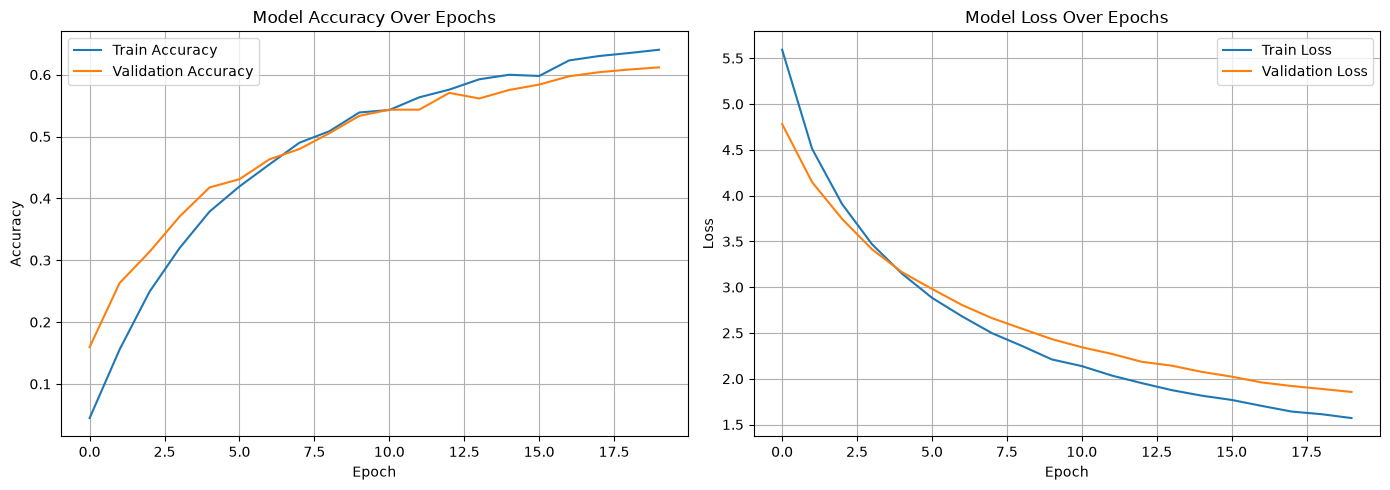

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Accuracy plot
axes[0].plot(history_df["accuracy"], label="Train Accuracy")
axes[0].plot(history_df["val_accuracy"], label="Validation Accuracy")
axes[0].set_title("Model Accuracy Over Epochs")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Accuracy")
axes[0].legend()
axes[0].grid(True)

# Loss plot
axes[1].plot(history_df["loss"], label="Train Loss")
axes[1].plot(history_df["val_loss"], label="Validation Loss")
axes[1].set_title("Model Loss Over Epochs")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Loss")
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.show()


### 9. Model Evaluation on Official Showroom Test Set (Cropped BBoxes)


In [ ]:
test_rows = []
for rel_path in test_lines:
    parts = rel_path.split("/")
    make_id = int(parts[0])
    model_id = int(parts[1])
    image_name = parts[3]

    # Parse bounding box from label file
    label_file = os.path.join(LABEL_DIR, os.path.splitext(rel_path)[0] + ".txt")
    with open(label_file, "r") as lf:
        lbl_lines = lf.readlines()
    
    viewpoint = int(lbl_lines[0].strip())
    x1, y1, x2, y2 = [int(v) for v in lbl_lines[2].strip().split()]

    test_rows.append({
        "image": image_name,
        "make_id": make_id,
        "model_id": model_id,
        "make_name": make_names[make_id - 1],
        "class_name": model_names[model_id - 1],
        "label": model_to_label[model_id],
        "viewpoint": viewpoint,
        "bbox_x1": x1,
        "bbox_y1": y1,
        "bbox_x2": x2,
        "bbox_y2": y2,
        "file_path": os.path.join(IMG_DIR, rel_path)
    })

test_df = pd.DataFrame(test_rows)

test_generator = BBoxDataGenerator(
    df=test_df,
    batch_size=BATCH_SIZE,
    target_size=IMG_SIZE,
    num_classes=NUM_CLASSES,
    datagen=None,
    shuffle=False,
    workers=16
)

test_loss, test_accuracy = model.evaluate(test_generator)
print(f"Test loss: {test_loss:.4f}")
print(f"Test accuracy: {test_accuracy:.4f}")

test_generator.close()


/home/cloudyrelic/e-con/tf-env/lib/python3.11/site-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


466/467 ━━━━━━━━━━━━━━━━━━━━ 0s 343ms/step - accuracy: 0.6520 - loss: 1.7292

E0000 00:00:1788797994.355625    2923 cuda_timer.cc:87] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
E0000 00:00:1788797996.042250    2923 cuda_timer.cc:87] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
E0000 00:00:1788798000.486325    2923 cuda_timer.cc:87] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


467/467 ━━━━━━━━━━━━━━━━━━━━ 178s 380ms/step - accuracy: 0.6522 - loss: 1.7271
Test loss: 1.7271
Test accuracy: 0.6522


### 10. Save Model and Standard Weights


In [ ]:
# Save entire model
model.save("showroom_bbox_b0_finetuned.keras")

# Save standard weights file (.weights.h5)
model.save_weights("showroom_bbox_b0_finetuned.weights.h5")
print("Saved showroom_bbox_b0.keras and showroom_bbox_b0.weights.h5 successfully!")


Saved showroom_bbox_b0.keras and showroom_bbox_b0.weights.h5 successfully!
